# E-Commerce Customer Analytics
## Phase 3 — RFM Analysis
**Dataset:** Olist Brazilian E-Commerce (Cleaned Master Table)  
**Goal:** Segment customers into meaningful groups based on their purchasing behaviour
using the RFM framework — Recency, Frequency, and Monetary value.

### What is RFM?
RFM is a proven marketing framework used to rank and segment customers based on three dimensions:

| Dimension | Question It Answers | Why It Matters |
|---|---|---|
| **R — Recency** | How recently did this customer last buy? | Recent buyers are more likely to buy again |
| **F — Frequency** | How many times have they bought? | Frequent buyers are more loyal |
| **M — Monetary** | How much have they spent in total? | High spenders drive disproportionate revenue |

By scoring each customer on all three dimensions, we can identify segments like
'Champions' (bought recently, often, and spent a lot) vs 'At Risk' (used to buy often but haven't recently).

---
## 1. Import Libraries & Configure Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Absolute paths — consistent across all notebooks
PROJECT_ROOT   = os.path.expanduser('~/Desktop/ecommerce-customer-analytics')
PROCESSED_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed') + '/'
DOCS_PATH      = os.path.join(PROJECT_ROOT, 'docs')

os.makedirs(DOCS_PATH, exist_ok=True)

print('Libraries loaded ✅')

Libraries loaded ✅


---
## 2. Load the Cleaned Master Table
We load the output from Phase 2 — the single clean table with one row per delivered order.

In [2]:
# Load the master cleaned table produced in Phase 2
master = pd.read_csv(PROCESSED_PATH + 'master_orders_clean.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print(f'Master table loaded: {master.shape[0]:,} rows, {master.shape[1]} columns')
print(f'Date range: {master["order_purchase_timestamp"].min().date()} to {master["order_purchase_timestamp"].max().date()}')
print(f'Unique customers: {master["customer_unique_id"].nunique():,}')

Master table loaded: 96,442 rows, 21 columns
Date range: 2016-10-03 to 2018-08-29
Unique customers: 93,323


---
## 3. Define the Snapshot Date
Recency is always calculated relative to a fixed reference point in time — called the snapshot date.
This represents 'today' from the perspective of the analysis.

We use the day after the last order in the dataset as our snapshot date.
This is standard practice — it ensures no customer has a recency of 0 days,
and keeps the analysis grounded in the actual timeframe of the data.

In [3]:
# Set snapshot date to the day after the most recent order in the dataset
# This is the reference point for calculating how recently each customer last bought
snapshot_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print(f'Latest order in dataset: {master["order_purchase_timestamp"].max().date()}')
print(f'Snapshot date (our reference point): {snapshot_date.date()}')

Latest order in dataset: 2018-08-29
Snapshot date (our reference point): 2018-08-30


---
## 4. Calculate RFM Metrics
For each unique customer we calculate three values:
- **Recency**: days since their last purchase (lower = more recent = better)
- **Frequency**: total number of orders placed
- **Monetary**: total amount spent across all orders

In [4]:
# Group by customer_unique_id to compute one row per customer
# agg() lets us apply different aggregation functions to different columns simultaneously
rfm = master.groupby('customer_unique_id').agg(

    # RECENCY: days between the customer's most recent order and the snapshot date
    # .max() gives the most recent purchase date, then we subtract from snapshot_date
    recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),

    # FREQUENCY: total number of orders placed by this customer
    # nunique() counts distinct order IDs to avoid double-counting
    frequency=('order_id', 'nunique'),

    # MONETARY: total amount spent by this customer across all orders
    # We exclude revenue outliers to prevent a few extreme orders from distorting scores
    monetary=('total_payment', 'sum')

).reset_index()

print(f'RFM table shape: {rfm.shape}')
print(f'\nRFM Summary Statistics:')
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

RFM table shape: (93323, 4)

RFM Summary Statistics:
        recency  frequency  monetary
count  93323.00   93323.00  93323.00
mean     237.89       1.03    165.20
std      152.54       0.21    226.34
min        1.00       1.00      9.59
25%      114.00       1.00     63.06
50%      219.00       1.00    107.78
75%      346.00       1.00    182.54
max      695.00      15.00  13664.08


---
## 5. Score Each Customer (1–5)
Raw RFM values (e.g. '42 days', 'R$310') are hard to compare across customers.
We convert them into scores from 1 to 5 using quintiles — dividing customers into
5 equal-sized groups based on their relative standing.

**Important:** For Recency, the scoring is reversed — a lower number of days
means a more recent purchase, which is better, so it gets a higher score.

In [5]:
# pd.qcut() divides customers into 5 equal-sized groups (quintiles)
# labels=[5,4,3,2,1] means the best group gets 5 and the worst gets 1

# RECENCY SCORE: reversed because fewer days = more recent = better
# The customer who bought yesterday should score 5, not 1
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# FREQUENCY SCORE: more orders = higher score
# duplicates='drop' handles ties gracefully where multiple customers have the exact same value
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# MONETARY SCORE: higher spend = higher score
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combine the three scores into a single RFM score string (e.g. '555' = best customer)
# This composite score is used to assign customer segments in the next step
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

# Also create a single numeric RFM total (sum of all three scores, max = 15)
# Useful for quick ranking — higher total = more valuable customer overall
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print('RFM scores assigned ✅')
print(rfm[['customer_unique_id', 'recency', 'frequency', 'monetary',
           'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_total']].head(10))

RFM scores assigned ✅
                 customer_unique_id  recency  frequency  monetary  R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98        4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38        4   
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18        3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76        4   

   F_score  M_score RFM_score  RFM_total  
0        1        4       414          9  
1        1        1       411    

---
## 6. Assign Customer Segments
We map RFM score combinations to human-readable segment names.
These segments are based on widely used RFM segmentation conventions
and are directly actionable for marketing and retention strategies.

In [6]:
# Segmentation function based on R and F scores
# M score is captured in the monetary metric but R and F are the strongest predictors of future behaviour so we use them as primary segment drivers
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    # Champions: bought very recently, buy often, spend the most
    if r >= 4 and f >= 4:
        return 'Champions'

    # Loyal Customers: buy frequently but not necessarily just recently
    elif f >= 3 and r >= 3:
        return 'Loyal Customers'

    # Potential Loyalists: recent buyers who could become loyal with nurturing
    elif r >= 4 and f <= 2:
        return 'Potential Loyalists'

    # Recent Customers: bought recently for the first time, low frequency
    elif r >= 3 and f == 1:
        return 'Recent Customers'

    # Promising: fairly recent, starting to buy more
    elif r >= 3 and f == 2:
        return 'Promising'

    # Need Attention: above average but showing signs of slowing down
    elif r == 3 and f == 3:
        return 'Need Attention'

    # About to Sleep: below average recency and frequency — fading away
    elif r == 2 and f <= 2:
        return 'About to Sleep'

    # At Risk: used to buy often but haven't recently — need re-engagement
    elif r <= 2 and f >= 3:
        return 'At Risk'

    # Cannot Lose Them: made big purchases in the past but haven't returned
    elif r <= 2 and m >= 4:
        return 'Cannot Lose Them'

    # Hibernating: low recency, low frequency — mostly inactive
    elif r <= 2 and f <= 2:
        return 'Hibernating'

    # Lost: lowest scores across all dimensions
    else:
        return 'Lost'

# Apply the segmentation function to every row
rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Summary of segment sizes
segment_counts = rfm['segment'].value_counts()
print('Customer Segment Distribution:')
print(segment_counts.to_string())

Customer Segment Distribution:
segment
At Risk                22213
Loyal Customers        18825
Potential Loyalists    14979
Champions              14956
About to Sleep          7427
Hibernating             4706
Recent Customers        3709
Promising               3661
Cannot Lose Them        2847


---
## 7. Visualise the Segments
### 7a. Segment Size Distribution

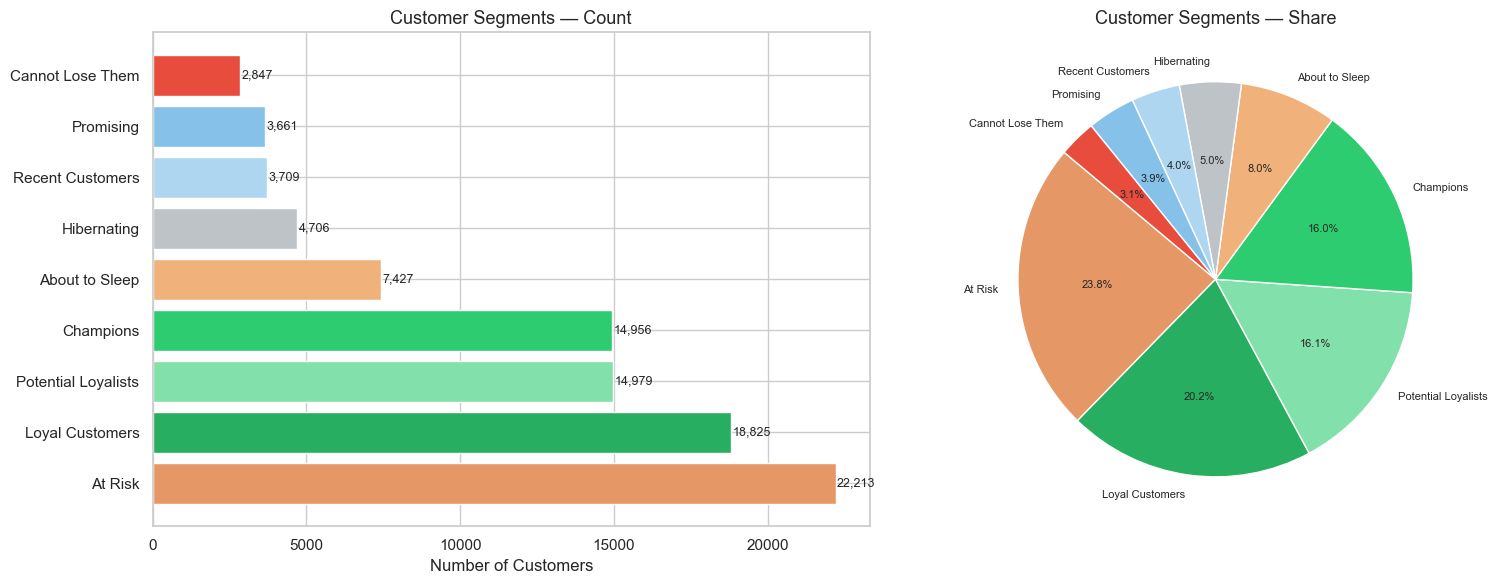

In [7]:
# Define a consistent colour palette for segments
# Green tones for high-value segments, orange/red for at-risk segments
segment_colors = {
    'Champions':           '#2ECC71',
    'Loyal Customers':     '#27AE60',
    'Potential Loyalists': '#82E0AA',
    'Recent Customers':    '#AED6F1',
    'Promising':           '#85C1E9',
    'Need Attention':      '#F9E79F',
    'About to Sleep':      '#F0B27A',
    'At Risk':             '#E59866',
    'Cannot Lose Them':    '#E74C3C',
    'Hibernating':         '#BDC3C7',
    'Lost':                '#95A5A6',
}

# Sort segments by count for a cleaner chart
sorted_segments = rfm['segment'].value_counts()
bar_colors = [segment_colors.get(s, '#AAAAAA') for s in sorted_segments.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Horizontal bar chart ---
axes[0].barh(sorted_segments.index, sorted_segments.values, color=bar_colors)
axes[0].set_title('Customer Segments — Count', fontsize=13)
axes[0].set_xlabel('Number of Customers')
# Add value labels to each bar for easy reading
for i, v in enumerate(sorted_segments.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# --- Right: Pie chart for share ---
axes[1].pie(
    sorted_segments.values,
    labels=sorted_segments.index,
    autopct='%1.1f%%',
    colors=bar_colors,
    startangle=140,
    textprops={'fontsize': 8}
)
axes[1].set_title('Customer Segments — Share', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'rfm_segment_distribution.png'), dpi=150)
plt.show()

### 7b. Average RFM Metrics by Segment
This chart shows how each segment differs in terms of recency, frequency, and monetary value.
It validates that our segments are meaningfully different from each other.

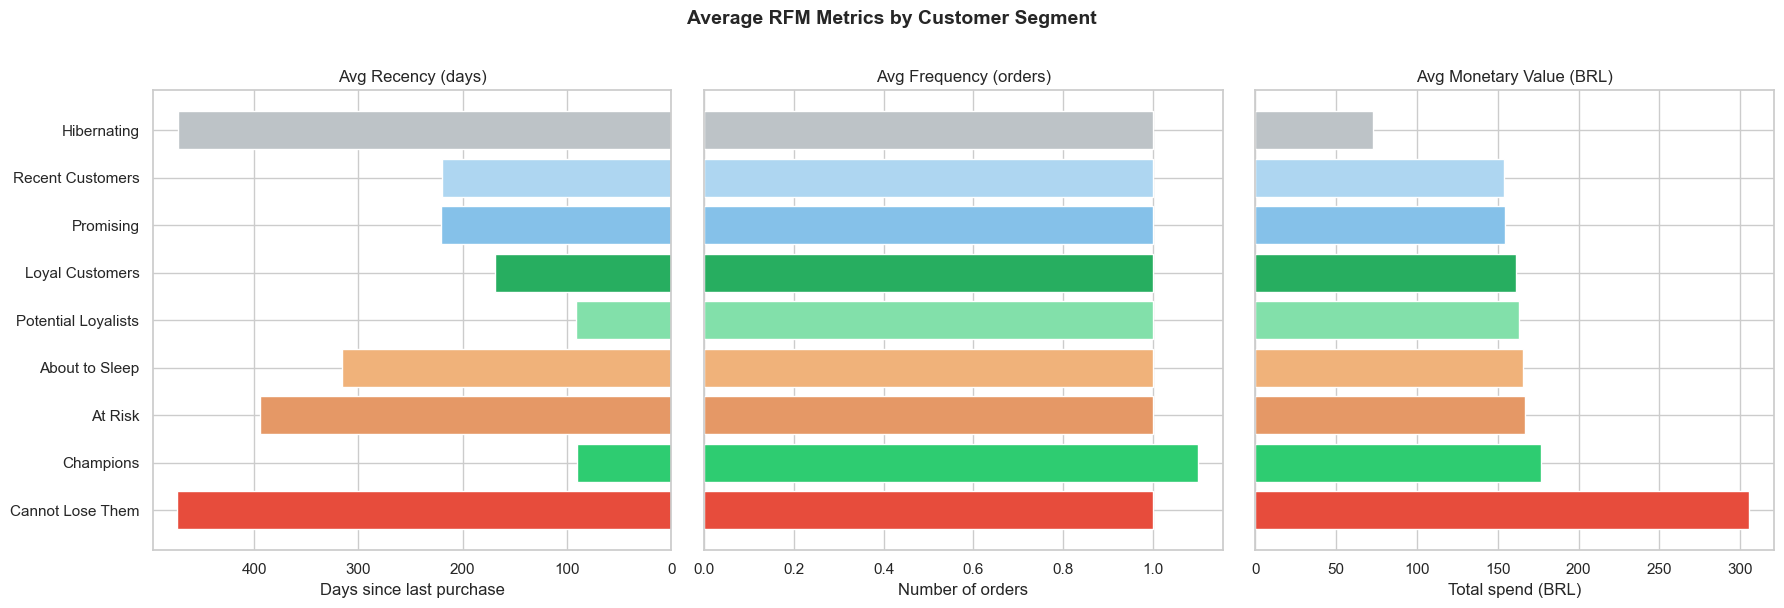

In [8]:
# Calculate average R, F, M values per segment
segment_summary = rfm.groupby('segment').agg(
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    customer_count=('customer_unique_id', 'count')
).round(1).reset_index()

# Sort by average monetary value descending
segment_summary = segment_summary.sort_values('avg_monetary', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = [segment_colors.get(s, '#AAAAAA') for s in segment_summary['segment']]

# Recency (lower is better — recent purchase)
axes[0].barh(segment_summary['segment'], segment_summary['avg_recency'], color=colors)
axes[0].set_title('Avg Recency (days)', fontsize=12)
axes[0].set_xlabel('Days since last purchase')
axes[0].invert_xaxis()  # Flip axis so shorter bars = better (more recent)

# Frequency
axes[1].barh(segment_summary['segment'], segment_summary['avg_frequency'], color=colors)
axes[1].set_title('Avg Frequency (orders)', fontsize=12)
axes[1].set_xlabel('Number of orders')
axes[1].set_yticklabels([])  # Hide y-axis labels — already shown on left chart

# Monetary
axes[2].barh(segment_summary['segment'], segment_summary['avg_monetary'], color=colors)
axes[2].set_title('Avg Monetary Value (BRL)', fontsize=12)
axes[2].set_xlabel('Total spend (BRL)')
axes[2].set_yticklabels([])

plt.suptitle('Average RFM Metrics by Customer Segment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'rfm_metrics_by_segment.png'), dpi=150, bbox_inches='tight')
plt.show()

### 7c. Revenue Contribution by Segment
Which segments generate the most total revenue? This tells us where to focus
retention and growth efforts from a business value perspective.

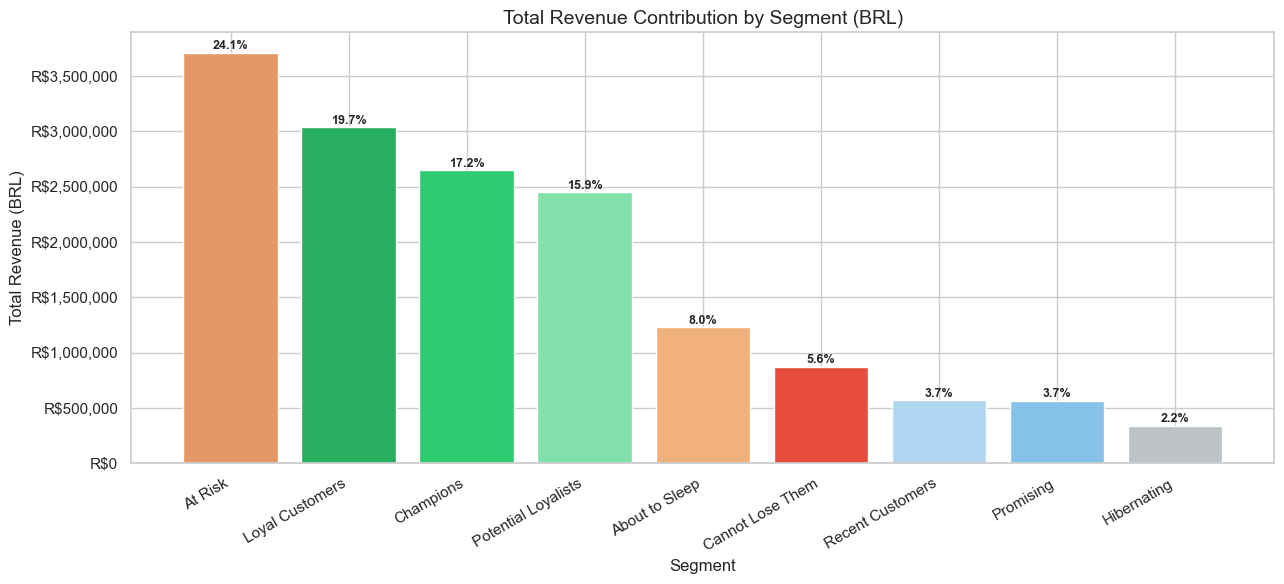

Revenue by Segment:
  At Risk                R$3,709,224.49  (24.1%)
  Loyal Customers        R$3,037,088.37  (19.7%)
  Champions              R$2,646,998.15  (17.2%)
  Potential Loyalists    R$2,447,313.54  (15.9%)
  About to Sleep         R$1,229,695.33  (8.0%)
  Cannot Lose Them       R$  870,296.88  (5.6%)
  Recent Customers       R$  570,531.38  (3.7%)
  Promising              R$  564,408.24  (3.7%)
  Hibernating            R$  341,382.97  (2.2%)


In [9]:
# Calculate total revenue per segment
revenue_by_segment = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
revenue_pct = (revenue_by_segment / revenue_by_segment.sum() * 100).round(1)

bar_colors_rev = [segment_colors.get(s, '#AAAAAA') for s in revenue_by_segment.index]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(revenue_by_segment.index, revenue_by_segment.values, color=bar_colors_rev)

# Add percentage labels above each bar
for bar, pct in zip(bars, revenue_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f'{pct}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Total Revenue Contribution by Segment (BRL)', fontsize=14)
ax.set_xlabel('Segment')
ax.set_ylabel('Total Revenue (BRL)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'rfm_revenue_by_segment.png'), dpi=150)
plt.show()

print('Revenue by Segment:')
for seg, rev, pct in zip(revenue_by_segment.index, revenue_by_segment.values, revenue_pct.values):
    print(f'  {seg:<22} R${rev:>12,.2f}  ({pct}%)')

### 7d. RFM Score Heatmap
This heatmap shows the average monetary value for every combination of
Recency and Frequency scores. The top-right corner (high R, high F) should
show the highest monetary values — confirming our scoring logic is sound.

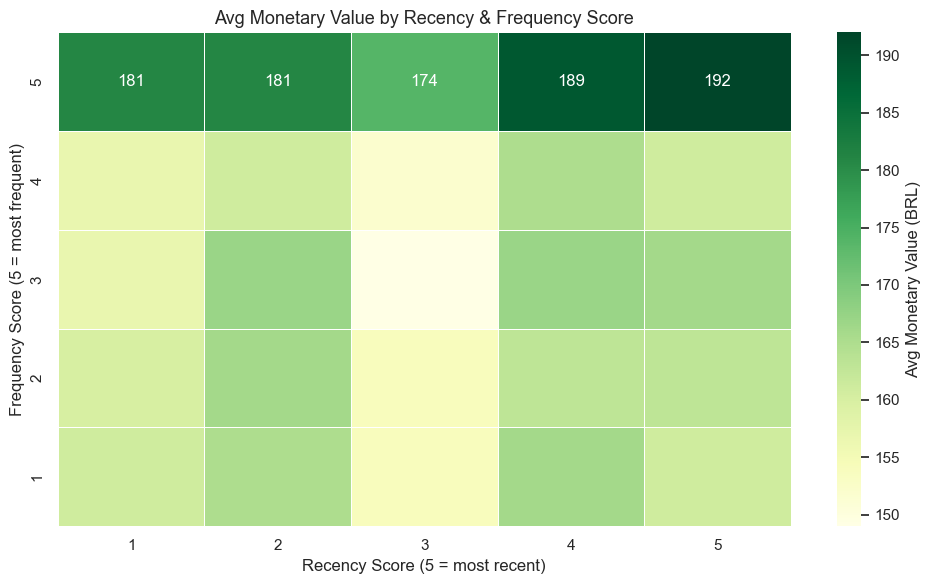

In [10]:
# Pivot table: rows = Frequency score, columns = Recency score, values = avg monetary
# This creates the grid we need for a heatmap
rfm_heatmap = rfm.pivot_table(
    index='F_score',
    columns='R_score',
    values='monetary',
    aggfunc='mean'
).round(0)

# Sort index descending so F=5 appears at the top (best frequency at top)
rfm_heatmap = rfm_heatmap.sort_index(ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(
    rfm_heatmap,
    annot=True,           # show the value inside each cell
    fmt='.0f',            # format as integer
    cmap='YlGn',          # yellow to green — higher value = darker green
    linewidths=0.5,
    cbar_kws={'label': 'Avg Monetary Value (BRL)'}
)
plt.title('Avg Monetary Value by Recency & Frequency Score', fontsize=13)
plt.xlabel('Recency Score (5 = most recent)')
plt.ylabel('Frequency Score (5 = most frequent)')
plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'rfm_heatmap.png'), dpi=150)
plt.show()

---
## 8. Segment Profiles
A detailed breakdown of each segment — size, average metrics, and recommended action.

In [11]:
# Build a comprehensive profile table for all segments
segment_profiles = rfm.groupby('segment').agg(
    customers=('customer_unique_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_orders=('frequency', 'mean'),
    avg_spend_brl=('monetary', 'mean'),
    total_revenue_brl=('monetary', 'sum')
).round(1).reset_index()

# Add revenue share column
segment_profiles['revenue_share_%'] = (
    segment_profiles['total_revenue_brl'] /
    segment_profiles['total_revenue_brl'].sum() * 100
).round(1)

# Add recommended action for each segment
actions = {
    'Champions':           'Reward them. Ask for reviews. Make them brand ambassadors.',
    'Loyal Customers':     'Upsell higher-value products. Ask for referrals.',
    'Potential Loyalists': 'Offer membership or loyalty programme to deepen engagement.',
    'Recent Customers':    'Provide onboarding support. Send helpful product tips.',
    'Promising':           'Create brand awareness. Offer free trials or incentives.',
    'Need Attention':      'Send personalised reactivation offers. Reconnect with them.',
    'About to Sleep':      'Share popular products and special discounts. Reconnect.',
    'At Risk':             'Send win-back campaign with personalised offers urgently.',
    'Cannot Lose Them':    'Win back via renewals or newer products. Do not ignore.',
    'Hibernating':         'Offer relevant products and special discounts to re-engage.',
    'Lost':                'Revive interest with targeted campaigns or accept the loss.',
}
segment_profiles['recommended_action'] = segment_profiles['segment'].map(actions)

# Sort by total revenue descending
segment_profiles = segment_profiles.sort_values('total_revenue_brl', ascending=False)

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.1f}'.format)
print(segment_profiles.to_string(index=False))

            segment  customers  avg_recency_days  avg_orders  avg_spend_brl  total_revenue_brl  revenue_share_%                                          recommended_action
            At Risk      22213             394.6         1.0          167.0          3709224.5             24.1   Send win-back campaign with personalised offers urgently.
    Loyal Customers      18825             168.8         1.0          161.3          3037088.4             19.7            Upsell higher-value products. Ask for referrals.
          Champions      14956              90.2         1.1          177.0          2646998.2             17.2  Reward them. Ask for reviews. Make them brand ambassadors.
Potential Loyalists      14979              90.9         1.0          163.4          2447313.5             15.9 Offer membership or loyalty programme to deepen engagement.
     About to Sleep       7427             316.2         1.0          165.6          1229695.3              8.0    Share popular products an

---
## 9. RFM Summary Statistics

In [12]:
print('=' * 60)
print('RFM ANALYSIS SUMMARY')
print('=' * 60)
print(f'Total customers analysed:    {len(rfm):,}')
print(f'Total segments identified:   {rfm["segment"].nunique()}')
print(f'Snapshot date used:          {snapshot_date.date()}')
print()

# Top 3 segments by size
top3_size = rfm['segment'].value_counts().head(3)
print('Top 3 Segments by Customer Count:')
for seg, count in top3_size.items():
    pct = count / len(rfm) * 100
    print(f'  {seg:<22} {count:>6,} customers ({pct:.1f}%)')
print()

# Top 3 segments by revenue
top3_rev = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False).head(3)
print('Top 3 Segments by Revenue:')
for seg, rev in top3_rev.items():
    pct = rev / rfm['monetary'].sum() * 100
    print(f'  {seg:<22} R${rev:>12,.2f} ({pct:.1f}%)')
print()

# Champions profile
champions = rfm[rfm['segment'] == 'Champions']
if len(champions) > 0:
    print(f'Champions Profile:')
    print(f'  Count:         {len(champions):,}')
    print(f'  Avg Recency:   {champions["recency"].mean():.0f} days')
    print(f'  Avg Orders:    {champions["frequency"].mean():.1f}')
    print(f'  Avg Spend:     R${champions["monetary"].mean():,.2f}')

print('=' * 60)
print('\n✅ RFM Analysis complete. Proceed to Phase 4 — Clustering.')

RFM ANALYSIS SUMMARY
Total customers analysed:    93,323
Total segments identified:   9
Snapshot date used:          2018-08-30

Top 3 Segments by Customer Count:
  At Risk                22,213 customers (23.8%)
  Loyal Customers        18,825 customers (20.2%)
  Potential Loyalists    14,979 customers (16.1%)

Top 3 Segments by Revenue:
  At Risk                R$3,709,224.49 (24.1%)
  Loyal Customers        R$3,037,088.37 (19.7%)
  Champions              R$2,646,998.15 (17.2%)

Champions Profile:
  Count:         14,956
  Avg Recency:   90 days
  Avg Orders:    1.1
  Avg Spend:     R$176.99

✅ RFM Analysis complete. Proceed to Phase 4 — Clustering.


---
## 10. Save RFM Table
We save the full RFM table with scores and segments to `data/processed/`.
This will be used as input for Phase 4 (K-Means Clustering).

In [13]:
# Save the RFM results for use in downstream phases
rfm_output_path = os.path.join(PROCESSED_PATH, 'rfm_scores.csv')
rfm.to_csv(rfm_output_path, index=False)

# Also save the segment summary for use in the Tableau dashboard
profiles_output_path = os.path.join(PROCESSED_PATH, 'rfm_segment_profiles.csv')
segment_profiles.to_csv(profiles_output_path, index=False)

print(f'✅ RFM scores saved to:          {rfm_output_path}')
print(f'✅ Segment profiles saved to:    {profiles_output_path}')
print(f'Rows: {len(rfm):,} | Columns: {rfm.shape[1]}')

✅ RFM scores saved to:          /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/rfm_scores.csv
✅ Segment profiles saved to:    /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/rfm_segment_profiles.csv
Rows: 93,323 | Columns: 10
